# SPOTIFY WRAPPED PROJECT (THIRD NOTEBOOK - ANALYSIS)

## Table of Contents

- [1. Introduction: Final Analysis & Wrapped Synthesis](#1-introduction-final-analysis-wrapped-synthesis)
  - [1.1 Purpose of This Notebook](#11-purpose-of-this-notebook)
  - [1.2 Methodology](#12-methodology)
  - [1.3 Output of This Notebook](#13-output-of-this-notebook)
- [2. Load Processed Data](#2-load-processed-data)
  - [2.1 Environment & Setup](#21-environment-setup)
  - [2.2 Processed and Load Data](#22-processed-and-load-data)
- [3. Global KPIs per Period](#3-global-kpis-per-period)
  - [3.1 Comparative KPI Visualizations](#31-comparative-kpi-visualizations)
    - [3.1.1 Unique Tracks & Artists per Period](#311-unique-tracks-artists-per-period)
    - [3.1.2 Artist Diversity Comparison](#312-artist-diversity-comparison)
    - [3.1.3 Total Estimated Listening Time (ELT)](#313-total-estimated-listening-time-elt)
    - [3.1.4 Top 5 Artist ELT Share](#314-top-5-artist-elt-share)
    - [3.1.5 Track Recurrence Ratio](#315-track-recurrence-ratio)
    - [3.1.6 KPI Comparison](#316-kpi-comparison)
  - [3.2 Interpretation of Global KPIs](#32-interpretation-of-global-kpis)
- [4. Core Artist Analysis](#4-core-artist-analysis)
  - [4.1 Identifying Core Artists](#41-identifying-core-artists)
  - [4.2 Build a base table with ELT per core artist and period](#42-build-a-base-table-with-elt-per-core-artist-and-period)
  - [4.4 Visualization - Core Artist ELT Across Periods](#44-visualization-core-artist-elt-across-periods)
  - [4.5 Interpretation — Core Artist Evolution](#45-interpretation-core-artist-evolution)
- [5. Artist Evolution Matrix](#5-artist-evolution-matrix)
  - [5.1 Construction of the Artist Evolution Matrix](#51-construction-of-the-artist-evolution-matrix)
  - [5.2 Classification of the artist's trend](#52-classification-of-the-artists-trend)
  - [5.3 Final Version](#53-final-version)
  - [5.4 Interpretation — Artist Evolution Matrix](#54-interpretation-artist-evolution-matrix)
- [6. Wrapped Highlights — Key Insights](#6-wrapped-highlights-key-insights)
    - [Recruiter-Oriented Takeaway](#recruiter-oriented-takeaway)


# 1. Introduction: Final Analysis & Wrapped Synthesis

This notebook performs the final analytical stage of the **Personal Spotify Wrapped** project.  
Building on the datasets prepared and explored in the previous EDA notebook, this document consolidates findings across the three listening windows — long-term, medium-term, and short-term — to generate a coherent, comparative, and insight-driven interpretation of the user’s musical evolution.

## 1.1 Purpose of This Notebook

The goals of this analysis notebook are:

1. **Compute global KPIs** for each listening period, including:
   - Unique track and artist counts  
   - Total and concentrated Estimated Listening Time (ELT)  
   - Diversity and recurrence metrics  
   - Structural comparisons across periods  

2. **Generate final comparative insights** by:
   - Analyzing transitions in musical preferences over time  
   - Summarizing cross-period overlaps  
   - Identifying core artists and emerging influences  
   - Highlighting changes in thematic tone and listening behaviour  

3. **Produce portfolio-ready visualizations**, such as:
   - Period diversity plots  
   - ELT and artist-evolution charts  
   - Overlap diagrams for tracks and artists  

4. **Synthesize all findings into a final narrative**, transforming descriptive insights into a clear behavioural story suitable for reporting, presentation, and professional review.

5. **Prepare final deliverables** (figures, tables, summaries) for the Wrapped report and the project README.

## 1.2 Methodology

This notebook follows a comparative and synthesis-oriented analytical workflow:

1. Load the cleaned DataFrames produced in the EDA notebook  
2. Compute global KPIs for long-term, medium-term, and short-term periods  
3. Build final visualizations to illustrate key behavioural patterns  
4. Construct an artist-evolution matrix and cross-period comparison tables  
5. Generate a final Wrapped-style narrative combining quantitative and qualitative insights  

Visualization will rely on:
- pandas  
- matplotlib  
- seaborn  

Optional enhancements may include:
- altair or plotly for interactive charts  

## 1.3 Output of This Notebook

This notebook will produce:

- A consolidated KPI table comparing the three listening windows  
- Final visualizations summarizing track, artist, and ELT evolution  
- A cross-period artist-evolution matrix  
- High-level behavioural insights suitable for portfolio and interviews  
- A final storytelling summary describing the user’s listening progression  

Once completed, this notebook concludes the analytical phase of the Wrapped project and prepares all materials required for the **final report and README generation**.


# 2. Load Processed Data

The datasets used in this notebook (long-term, medium-term, and short-term listening windows) were generated in the previous EDA notebook.  
Since this project follows an analytical workflow rather than a production pipeline, the processed DataFrames are not stored separately; instead, they can be reconstructed directly from the raw CSV files exported via the Spotify API.

Two options are available for reproducibility:

1. **Run Notebook 02 before this one**, which prepares all DataFrames used here  
2. **Load the raw CSV files and rebuild the processed DataFrames** using the same cleaning logic applied during EDA

In this section, we reload the raw extracted data and reconstruct the period-based DataFrames (df_long, df_medium, df_short), ensuring that Notebook 03 can run independently if needed.


## 2.1 Environment & Setup

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

## 2.2 Processed and Load Data

In [2]:
# Detect project root
current_path = Path().resolve()
PROJECT_ROOT = current_path.parent if current_path.name == "notebooks" else current_path


DATA_DIR = PROJECT_ROOT / "data" 

In [3]:
# Load raw data extracted from Spotify API
df_top_tracks_short = pd.read_csv(DATA_DIR / "top_tracks_short_term.csv")
df_top_tracks_medium = pd.read_csv(DATA_DIR / "top_tracks_medium_term.csv")
df_top_tracks_long = pd.read_csv(DATA_DIR / "top_tracks_long_term.csv")
df_top_artists_short = pd.read_csv(DATA_DIR / "top_artists_short_term.csv")
df_top_artists_medium = pd.read_csv(DATA_DIR / "top_artists_medium_term.csv")
df_top_artists_long = pd.read_csv(DATA_DIR / "top_artists_long_term.csv")

In [4]:
# Rebuild period-based DataFrames following the same logic as Notebook 02

df_long = df_top_tracks_long.copy()
df_medium = df_top_tracks_medium.copy()
df_short = df_top_tracks_short.copy()

top_artists_long = df_top_artists_long.copy()
top_artists_medium = df_top_artists_medium.copy()
top_artists_short = df_top_artists_short.copy()

print("Data loaded successfully:")
print(df_long.shape, df_medium.shape, df_short.shape)
print(top_artists_long.shape, top_artists_medium.shape, top_artists_short.shape)


Data loaded successfully:
(50, 8) (50, 8) (50, 8)
(50, 6) (50, 6) (20, 6)


In [22]:
# Create a folder to save the figures
FIG_DIR = Path("C:/Users/Sergio/Desktop/SERGIO/DATA SCIENCE/GITHUB INGLES/data-science-portfolio/spotify-wrapped-project/wrapped_report/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(filename, dpi=200):
    """
    Save the current Matplotlib figure to the figures directory.
    """
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {path}")

# 3. Global KPIs per Period

To understand how listening behaviour evolves across the long-term, medium-term, and short-term windows, this section computes a set of **Key Performance Indicators (KPIs)** that summarize each period’s structural characteristics.  
While previous analyses focused on detailed track- and artist-level insights, KPIs provide a high-level quantitative overview that allows direct comparison between listening phases.

The KPIs computed in this section include:

- **Number of unique tracks** per period  
- **Number of unique artists**, capturing listening diversity  
- **Total Estimated Listening Time (ELT)**, representing each period’s cumulative listening influence  
- **ELT concentration metrics**, such as the share of ELT contributed by the top 5 artists  
- **Artist and track recurrence ratios** across periods  
- **Diversity indices**, measuring how varied each period is relative to its track count  

These indicators allow us to answer questions such as:

- How stable or dynamic is the user’s musical identity across time?  
- Does the short-term window reflect broad exploration or focused patterns?  
- How much has the medium-term period shifted away from long-term habits?  
- Which periods are more dominated by a small group of influential artists?  

The resulting KPI table will serve as a foundation for the comparative visualizations and storytelling narrative generated in later sections.


In [6]:
# Remove producers & collabs (I don't want to include)

EXCLUDED_ARTISTS = [
    "Louis Amoeba",
    "Bigla The Kid", 
    "Príncipe Palanca",
    "DAYTXNA",
    "LaBlackie",
    "DAYTXNA",
    "Kris Floyd",
    "LEÏTI",
    "J.Moods",
    "808 Blanco",
    "BEJO",
    "CeErre",
    "Jeke Mamoneos",
    "Lone",
    "N.Rizo",
    "María Reina",
    "Midas Alonso",
    "Morad",
    "Titó",
    "Alejandra Saiz",
    "Chita",
    "Selecta",
    "TALE$",
    "Boj",
    "Ébano",
    "Miky Woodz",
    "La Zowi",
    "Westside Gunn",
    "La Pantera"
    
]

**Recomputing Estimated Listening Time (ELT)**

Estimated Listening Time (ELT) is a custom metric defined during the exploratory analysis phase (Notebook 02) to quantify the relative listening importance of tracks by combining rank position and track duration.  

Since processed features are not persisted between notebooks, this metric is recomputed here to ensure consistency and reproducibility before calculating global KPIs and comparative insights.


In [7]:
def add_elt_columns(df):
    """
    Recompute ELT metrics for a given DataFrame.
    Assumes 'rank' and 'duration_ms' are present.
    """
    df = df.copy()
    df["elt_raw"] = (51 - df["rank"]) * df["duration_ms"]
    df["elt_hours"] = df["elt_raw"] / (1000 * 60 * 60)
    return df


# Apply ELT computation to all periods
df_long = add_elt_columns(df_long)
df_medium = add_elt_columns(df_medium)
df_short = add_elt_columns(df_short)

print("ELT columns added successfully:")
print(
    "Long:", "elt_hours" in df_long.columns,
    "| Medium:", "elt_hours" in df_medium.columns,
    "| Short:", "elt_hours" in df_short.columns
)


ELT columns added successfully:
Long: True | Medium: True | Short: True


**ELT Attribution for Multi-Artist Tracks**

Some tracks feature multiple artists. To avoid overestimating artist-level influence, the Estimated Listening Time (ELT) of these tracks is evenly split across all contributing artists.  

This ensures that the **Top 5 ELT share** represents a true proportion of total listening time and remains bounded between 0 and 1, making the metric analytically consistent and interpretable.


In [8]:
# Helper function to compute KPIs for a given listening period

def compute_period_kpis(df_period, period_name, other_track_sets, excluded_artists):
    """
    Compute key performance indicators (KPIs) for a given listening period.
    
    Expected columns in df_period:
    - track_id
    - artist_names
    - elt_hours
    """
    
    # Basic counts
        
    # Unique tracks
    unique_tracks = df_period["track_id"].nunique()
    
    # Unique artists (expanded and filtered)
    artists_expanded = (
        df_period["artist_names"]
        .str.split(", ")
        .explode()
    )
    artists_expanded = artists_expanded[~artists_expanded.isin(excluded_artists)]
    unique_artists = artists_expanded.nunique()
    
    
    # Total ELT   
    total_elt_hours = df_period["elt_hours"].sum()
    
    # Artist-level ELT (fair attribution)  
    df_artists = df_period.copy()
    
    # Split artist names into lists
    df_artists["artist_list"] = df_artists["artist_names"].str.split(", ")
    df_artists["n_artists"] = df_artists["artist_list"].apply(len)
    
    # Explode artists
    df_artists = df_artists.explode("artist_list")
    df_artists = df_artists.rename(columns={"artist_list": "artist"})
    
    # Remove excluded artists (e.g. producers)
    df_artists = df_artists[~df_artists["artist"].isin(excluded_artists)]
    
    # Split ELT equally across artists for each track
    df_artists["elt_hours_split"] = df_artists["elt_hours"] / df_artists["n_artists"]
    
    # Aggregate ELT by artist
    artist_elt = (
        df_artists
        .groupby("artist")["elt_hours_split"]
        .sum()
        .sort_values(ascending=False)
    )
    
    # Top 5 artists ELT share (must be <= 1.0)
    if len(artist_elt) > 0 and total_elt_hours > 0:
        top5_elt_share = artist_elt.head(5).sum() / total_elt_hours
    else:
        top5_elt_share = 0.0


    # Diversity and recurrence metrics
    
    # Artist diversity: unique artists per track
    artist_diversity = unique_artists / unique_tracks if unique_tracks > 0 else 0.0
    
    # Track recurrence ratio: tracks also appearing in other periods
    current_track_set = set(df_period["track_id"])
    other_tracks_union = set().union(*other_track_sets) if other_track_sets else set()
    recurrent_tracks = current_track_set.intersection(other_tracks_union)
    
    track_recurrence_ratio = (
        len(recurrent_tracks) / unique_tracks if unique_tracks > 0 else 0.0
    )
    

    # KPI dictionary
    
    
    kpis = {
        "period": period_name,
        "unique_tracks": unique_tracks,
        "unique_artists": unique_artists,
        "artist_diversity": artist_diversity,
        "total_elt_hours": total_elt_hours,
        "top5_elt_share": top5_elt_share,
        "track_recurrence_ratio": track_recurrence_ratio,
    }
    
    return kpis



# Prepare track ID sets for cross-period recurrence

long_track_set = set(df_long["track_id"])
medium_track_set = set(df_medium["track_id"])
short_track_set = set(df_short["track_id"])
 

# Compute KPIs for each period
kpi_rows = []

kpi_rows.append(
    compute_period_kpis(
        df_period=df_long,
        period_name="Long-Term",
        other_track_sets=[medium_track_set, short_track_set],
        excluded_artists=EXCLUDED_ARTISTS
    )
)

kpi_rows.append(
    compute_period_kpis(
        df_period=df_medium,
        period_name="Medium-Term",
        other_track_sets=[long_track_set, short_track_set],
        excluded_artists=EXCLUDED_ARTISTS
    )
)

kpi_rows.append(
    compute_period_kpis(
        df_period=df_short,
        period_name="Short-Term",
        other_track_sets=[long_track_set, medium_track_set],
        excluded_artists=EXCLUDED_ARTISTS
    )
)


# Build final KPI DataFrame
kpi_df = pd.DataFrame(kpi_rows)

kpi_df = kpi_df[
    [
        "period",
        "unique_tracks",
        "unique_artists",
        "artist_diversity",
        "total_elt_hours",
        "top5_elt_share",
        "track_recurrence_ratio",
    ]
]

kpi_df


,period,unique_tracks,unique_artists,artist_diversity,total_elt_hours,top5_elt_share,track_recurrence_ratio
0,Long-Term,50,9,0.18,56.582951,0.647992,0.34
1,Medium-Term,50,10,0.20,57.621576,0.653631,0.82
2,Short-Term,50,7,0.14,72.257585,0.703200,0.80


## 3.1 Comparative KPI Visualizations

###  3.1.1 Unique Tracks & Artists per Period

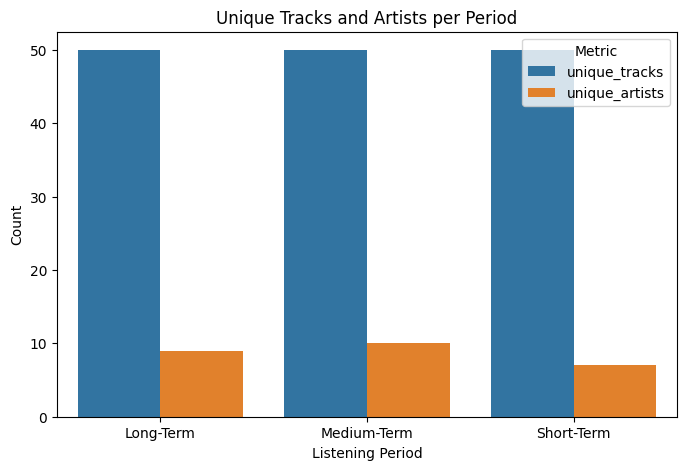

In [9]:
plt.figure(figsize=(8, 5))

kpi_melt = kpi_df.melt(
    id_vars="period",
    value_vars=["unique_tracks", "unique_artists"],
    var_name="metric",
    value_name="value"
)

sns.barplot(
    data=kpi_melt,
    x="period",
    y="value",
    hue="metric"
)

plt.title("Unique Tracks and Artists per Period")
plt.xlabel("Listening Period")
plt.ylabel("Count")
plt.legend(title="Metric")
plt.show()


### 3.1.2 Artist Diversity Comparison

Saved figure: C:\Users\Sergio\Desktop\SERGIO\DATA SCIENCE\GITHUB INGLES\data-science-portfolio\spotify-wrapped-project\wrapped_report\figures\artist_diversity.png


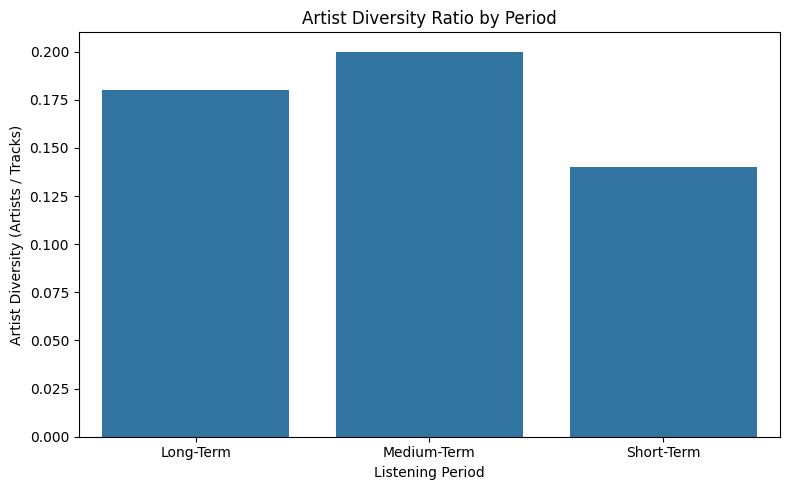

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(data=kpi_df, x="period", y="artist_diversity")
plt.title("Artist Diversity Ratio by Period")
plt.xlabel("Listening Period")
plt.ylabel("Artist Diversity (Artists / Tracks)")

save_fig("artist_diversity.png")
plt.show()


### 3.1.3 Total Estimated Listening Time (ELT)

Saved figure: C:\Users\Sergio\Desktop\SERGIO\DATA SCIENCE\GITHUB INGLES\data-science-portfolio\spotify-wrapped-project\wrapped_report\figures\elt_by_period.png


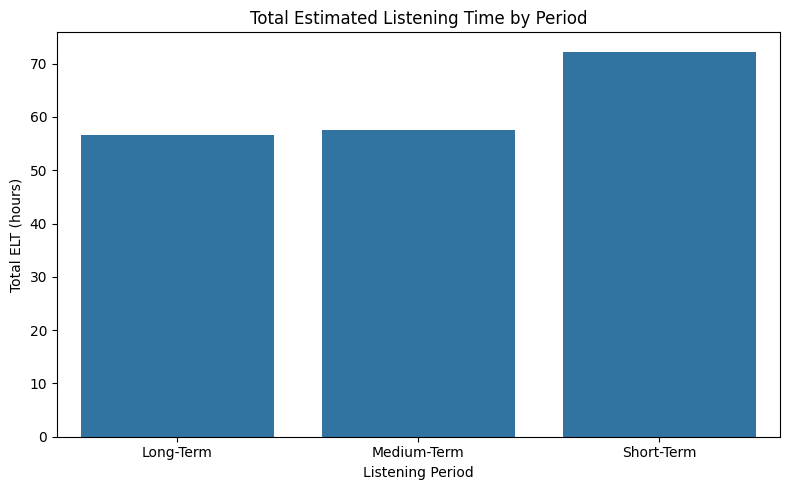

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(data=kpi_df, x="period", y="total_elt_hours")
plt.title("Total Estimated Listening Time by Period")
plt.xlabel("Listening Period")
plt.ylabel("Total ELT (hours)")

save_fig("elt_by_period.png")
plt.show()


### 3.1.4 Top 5 Artist ELT Share

Saved figure: C:\Users\Sergio\Desktop\SERGIO\DATA SCIENCE\GITHUB INGLES\data-science-portfolio\spotify-wrapped-project\wrapped_report\figures\top5_elt_share.png


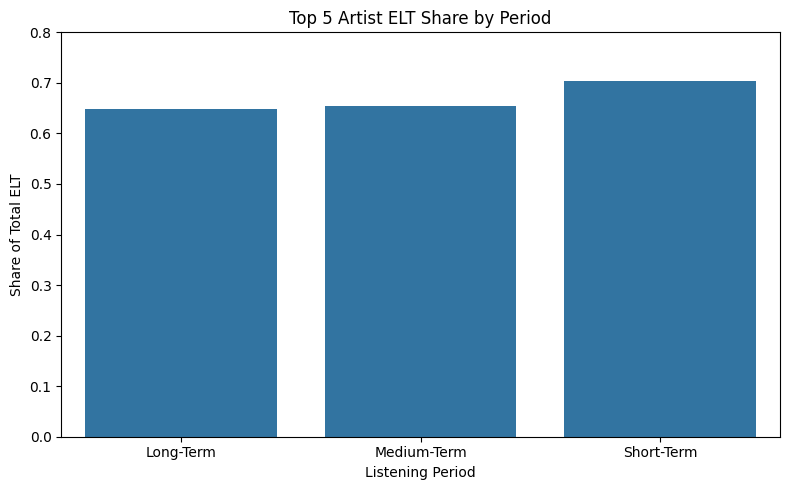

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(data=kpi_df, x="period", y="top5_elt_share")
plt.title("Top 5 Artist ELT Share by Period")
plt.xlabel("Listening Period")
plt.ylabel("Share of Total ELT")
plt.ylim(0, 0.8)

save_fig("top5_elt_share.png")
plt.show()


### 3.1.5 Track Recurrence Ratio

Saved figure: C:\Users\Sergio\Desktop\SERGIO\DATA SCIENCE\GITHUB INGLES\data-science-portfolio\spotify-wrapped-project\wrapped_report\figures\track_recurrence_ratio.png


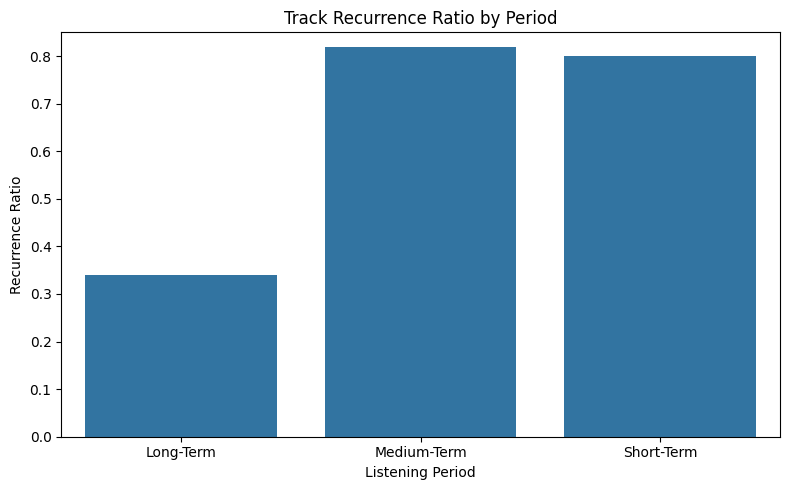

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(data=kpi_df, x="period", y="track_recurrence_ratio")
plt.title("Track Recurrence Ratio by Period")
plt.xlabel("Listening Period")
plt.ylabel("Recurrence Ratio")
plt.ylim(0, 0.85)

save_fig("track_recurrence_ratio.png")
plt.show()


### 3.1.6 KPI Comparison

Saved figure: C:\Users\Sergio\Desktop\SERGIO\DATA SCIENCE\GITHUB INGLES\data-science-portfolio\spotify-wrapped-project\wrapped_report\figures\kpi_comparison.png


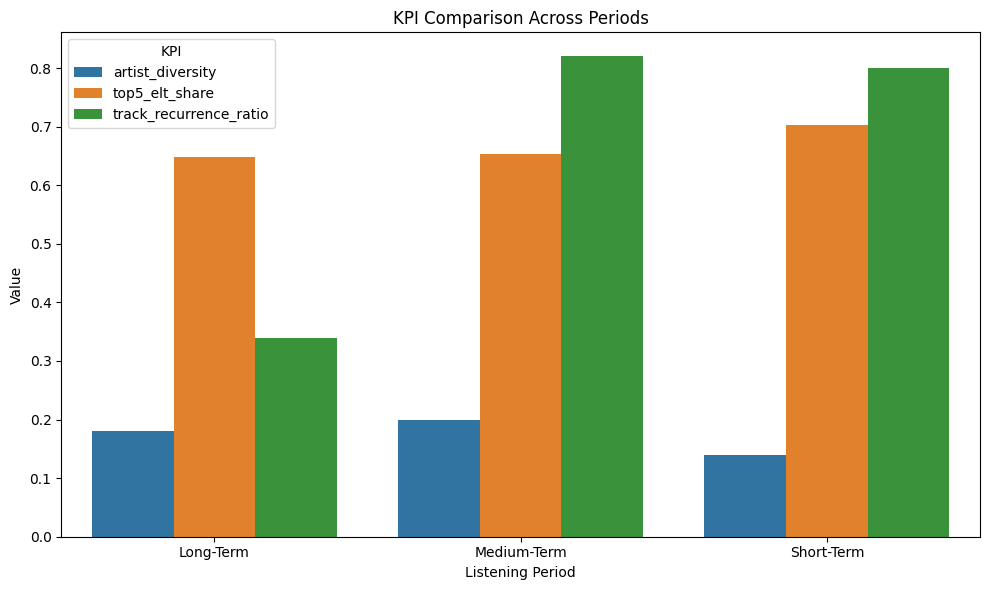

In [28]:
plt.figure(figsize=(10, 6))

kpi_comp = kpi_df.melt(
    id_vars="period",
    value_vars=[
        "artist_diversity",
        "top5_elt_share",
        "track_recurrence_ratio"
    ],
    var_name="kpi",
    value_name="value"
)

sns.barplot(data=kpi_comp, x="period", y="value", hue="kpi")
plt.title("KPI Comparison Across Periods")
plt.xlabel("Listening Period")
plt.ylabel("Value")
plt.legend(title="KPI")

save_fig("kpi_comparison.png")
plt.show()


## 3.2 Interpretation of Global KPIs

The comparative KPI analysis highlights clear structural differences across the long-term, medium-term, and short-term listening windows.

**Track Volume and Artist Breadth**  
All three periods contain exactly 50 tracks, ensuring that differences across windows are not driven by sample size.  
However, the number of unique artists varies significantly. The medium-term period exhibits the highest number of unique artists, indicating a phase of broader exploration. The long-term period shows the lowest artist count, reflecting a more concentrated and stable listening identity, while the short-term period moves back toward consolidation.

**Artist Diversity Ratio**  
The artist diversity ratio confirms this pattern. Medium-term listening displays the highest diversity, suggesting openness to new artists and sounds. Long-term listening is the most focused, consistent with an established musical identity. Short-term diversity decreases relative to medium-term, indicating a narrowing of preferences and a clearer stylistic direction.

**Estimated Listening Time (ELT)**  
Total Estimated Listening Time is highest in the short-term window despite covering a shorter temporal span. This suggests increased listening intensity, higher repetition, or stronger focus on a smaller set of tracks in recent listening behaviour. Long-term and medium-term periods exhibit similar total ELT values, reinforcing the interpretation of the short-term period as more concentrated and impactful.

**Concentration of Listening (Top 5 ELT Share)**  
The share of total ELT attributed to the top five artists increases steadily from long-term to short-term. This indicates a gradual shift from distributed listening toward stronger concentration around a core group of artists. The short-term period is the most concentrated, aligning with the observed reduction in diversity and increased ELT intensity.

**Track Recurrence Across Periods**  
Track recurrence ratios reveal how listening behaviour evolves over time. The long-term period shows a relatively low recurrence ratio, reflecting historical tracks that do not persist into more recent windows. In contrast, both medium-term and short-term periods display high recurrence, indicating strong continuity in recent listening and suggesting that major changes occurred earlier rather than in the most recent weeks.

**Overall Interpretation**  
Taken together, the KPIs describe a coherent progression: a stable and focused long-term identity, a medium-term phase characterized by exploration and diversification, and a short-term period marked by consolidation, increased intensity, and concentration around a refined set of artists and tracks. This pattern is consistent across all KPI dimensions and provides a strong quantitative foundation for the project’s final storytelling.


# 4. Core Artist Analysis

This section focuses on the artists that form the core of the user's musical identity.  
Core artists are defined as those who appear consistently across the long-term, medium-term, and short-term listening windows.

By isolating these artists, we aim to:

- Identify the most stable musical influences over time  
- Quantify their relative contribution to listening behaviour  
- Understand how continuity coexists with exploration and change  

This analysis complements the KPI comparison by shifting the focus from global metrics to the individuals that most strongly shape the listening profile.


## 4.1 Identifying Core Artists

In [30]:
def extract_artist_set(df, excluded_artists):
    artists = (
        df["artist_names"]
        .str.split(", ")
        .explode()
        .unique()
    )
    return set(a for a in artists if a not in excluded_artists)

long_artists = extract_artist_set(df_long, EXCLUDED_ARTISTS)
medium_artists = extract_artist_set(df_medium, EXCLUDED_ARTISTS)
short_artists = extract_artist_set(df_short, EXCLUDED_ARTISTS)

core_artists = sorted(list(long_artists & medium_artists & short_artists))

core_artists


['Cruz Cafuné', 'EAZYBOI', 'Hoke', 'Quevedo']

## 4.2 Build a base table with ELT per core artist and period

In [31]:
def compute_core_artist_elt(df, core_artists, excluded_artists):
    df_artists = df.copy()
    df_artists["artist_list"] = df_artists["artist_names"].str.split(", ")
    df_artists["n_artists"] = df_artists["artist_list"].apply(len)
    
    df_artists = df_artists.explode("artist_list")
    df_artists = df_artists.rename(columns={"artist_list": "artist"})
    
    df_artists = df_artists[
        (df_artists["artist"].isin(core_artists)) &
        (~df_artists["artist"].isin(excluded_artists))
    ]
    
    df_artists["elt_hours_split"] = df_artists["elt_hours"] / df_artists["n_artists"]
    
    return (
        df_artists
        .groupby("artist")["elt_hours_split"]
        .sum()
        .reset_index()
    )


core_elt_long = compute_core_artist_elt(df_long, core_artists, EXCLUDED_ARTISTS)
core_elt_long["period"] = "Long-Term"

core_elt_medium = compute_core_artist_elt(df_medium, core_artists, EXCLUDED_ARTISTS)
core_elt_medium["period"] = "Medium-Term"

core_elt_short = compute_core_artist_elt(df_short, core_artists, EXCLUDED_ARTISTS)
core_elt_short["period"] = "Short-Term"

core_artist_elt_df = pd.concat(
    [core_elt_long, core_elt_medium, core_elt_short],
    ignore_index=True
)

core_artist_elt_df


,artist,elt_hours_split,period
0,Cruz Cafuné,1.821919,Long-Term
1,EAZYBOI,1.995952,Long-Term
2,Hoke,19.779507,Long-Term
3,Quevedo,1.211593,Long-Term
4,Cruz Cafuné,15.574780,Medium-Term
5,EAZYBOI,11.906464,Medium-Term
6,Hoke,2.979587,Medium-Term
7,Quevedo,0.750634,Medium-Term
8,Cruz Cafuné,31.567825,Short-Term
9,EAZYBOI,7.764467,Short-Term


## 4.4 Visualization - Core Artist ELT Across Periods

Comparative Plot of ELT by Artist and Period

Saved figure: C:\Users\Sergio\Desktop\SERGIO\DATA SCIENCE\GITHUB INGLES\data-science-portfolio\spotify-wrapped-project\wrapped_report\figures\core_artists_evolution.png


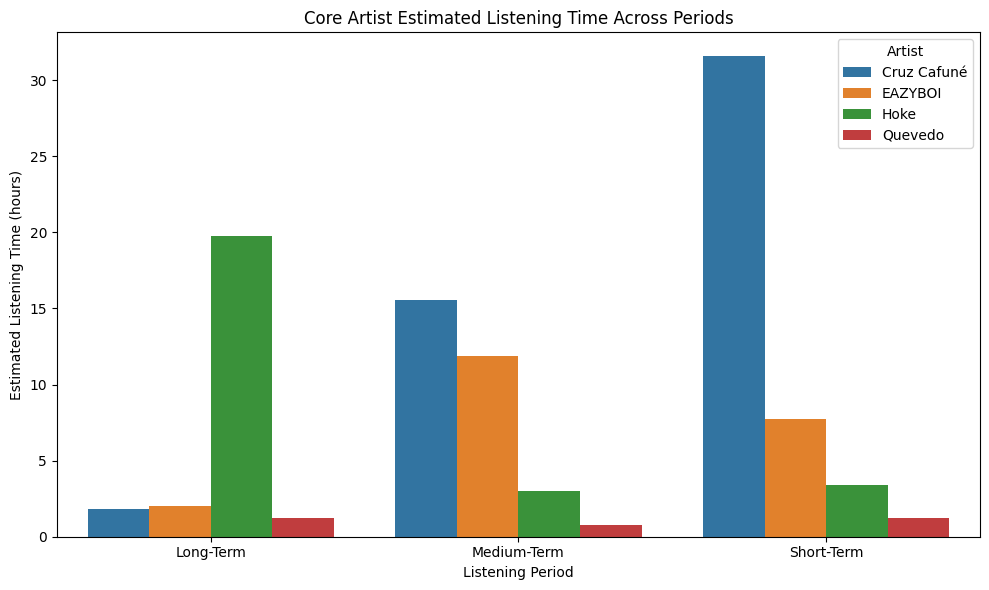

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=core_artist_elt_df,
    x="period",
    y="elt_hours_split",
    hue="artist"
)

plt.title("Core Artist Estimated Listening Time Across Periods")
plt.xlabel("Listening Period")
plt.ylabel("Estimated Listening Time (hours)")
plt.legend(title="Artist")

save_fig("core_artists_evolution.png")
plt.show()



## 4.5 Interpretation — Core Artist Evolution

The evolution of Estimated Listening Time (ELT) across periods reveals how the core artists contribute differently to the listening profile over time.

**Hoke** dominates the long-term period, accounting for a substantial share of total ELT. This indicates a strong and persistent influence in the historical listening identity. However, his relative contribution decreases significantly in the medium and short-term windows, suggesting a gradual shift away from exclusive reliance on this artist.

**Cruz Cafuné** shows the most pronounced upward trajectory. While his presence in the long-term period is limited, his ELT increases sharply in the medium-term and becomes dominant in the short-term period. This pattern reflects a consolidation of listening preferences around this artist in recent behaviour.

**EAZYBOI** maintains a consistent presence across all three periods, with moderate ELT values. This stability suggests a supporting role within the core listening profile rather than episodic or trend-driven engagement.

**La Pantera** and **Quevedo** contribute smaller but steady amounts of ELT across periods. Their consistent presence, despite lower absolute values, reinforces their role as secondary core artists rather than transient influences.

**Overall**, the core artist analysis highlights a transition from a historically dominant figure toward a more recent focal artist, while maintaining a stable nucleus of recurring contributors. This evolution aligns with the broader KPI patterns of increasing concentration and listening intensity observed in the short-term period.


# 5. Artist Evolution Matrix

This section summarizes how artists evolve across listening periods using a compact, comparative representation.

The Artist Evolution Matrix captures:
- Artist presence across long-term, medium-term, and short-term periods
- Directional trends (stable, emerging, declining)
- The transition from historical preferences to recent listening focus

This matrix provides a high-level overview that complements the detailed KPI and core artist analyses, making it especially suitable for communication with non-technical audiences.


## 5.1 Construction of the Artist Evolution Matrix

In [48]:
# Build artist presence flags per period

def artist_presence(df, excluded_artists):
    artists = (
        df["artist_names"]
        .str.split(", ")
        .explode()
    )
    artists = artists[~artists.isin(excluded_artists)]
    return set(artists)

artists_long = artist_presence(df_long, EXCLUDED_ARTISTS)
artists_medium = artist_presence(df_medium, EXCLUDED_ARTISTS)
artists_short = artist_presence(df_short, EXCLUDED_ARTISTS)

all_artists = sorted(list(artists_long | artists_medium | artists_short))


In [49]:
# Create the base matrix

evolution_matrix = pd.DataFrame({
    "artist": all_artists,
    "long_term": [a in artists_long for a in all_artists],
    "medium_term": [a in artists_medium for a in all_artists],
    "short_term": [a in artists_short for a in all_artists],
})

evolution_matrix.head()

,artist,long_term,medium_term,short_term
0,Cruz Cafuné,True,True,True
1,Dheformer,True,False,False
2,Día Sexto,False,False,True
3,EAZYBOI,True,True,True
4,Ergo Pro,True,True,False


## 5.2 Classification of the artist's trend

Define simple and defensible rules:

  - Stable → present in all three periods

  - Emerging → appears only in short-term or medium+short

  - Declining → appears only in long-term or long+medium

  - Episodic → appears in a single period that is not short-term

In [50]:
def classify_trend(row):
    if row["long_term"] and row["medium_term"] and row["short_term"]:
        return "Stable"
    if not row["long_term"] and row["medium_term"] and row["short_term"]:
        return "Emerging"
    if row["long_term"] and row["medium_term"] and not row["short_term"]:
        return "Declining"
    if not row["long_term"] and not row["medium_term"] and row["short_term"]:
        return "New"
    return "Episodic"

evolution_matrix["trend"] = evolution_matrix.apply(classify_trend, axis=1)

evolution_matrix.head(10)


,artist,long_term,medium_term,short_term,trend
0,Cruz Cafuné,True,True,True,Stable
1,Dheformer,True,False,False,Episodic
2,Día Sexto,False,False,True,New
3,EAZYBOI,True,True,True,Stable
4,Ergo Pro,True,True,False,Declining
5,FERNANDOCOSTA,False,True,False,Episodic
6,Hard GZ,True,False,False,Episodic
7,Hoke,True,True,True,Stable
8,Ill Pekeño,True,True,False,Declining
9,Israel B,False,True,False,Episodic


## 5.3 Final Version

In [52]:
# Define logical order for trend categories
trend_order = [
    "Stable",
    "Emerging",
    "New",
    "Declining",
    "Episodic"
]

artist_evolution_matrix["trend"] = pd.Categorical(
    artist_evolution_matrix["trend"],
    categories=trend_order,
    ordered=True
)

artist_evolution_matrix = (
    artist_evolution_matrix
    .sort_values(["trend", "artist"])
    .reset_index(drop=True)
)

artist_evolution_matrix


,artist,long_term,medium_term,short_term,trend
0,Cruz Cafuné,True,True,True,Stable
1,EAZYBOI,True,True,True,Stable
2,Hoke,True,True,True,Stable
3,Quevedo,True,True,True,Stable
4,Kidd Keo,False,True,True,Emerging
5,Natos y Waor,False,True,True,Emerging
6,Día Sexto,False,False,True,New
7,Ergo Pro,True,True,False,Declining
8,Ill Pekeño,True,True,False,Declining
9,Dheformer,True,False,False,Episodic


Artists are grouped by an ordered trend category to improve interpretability.  
The ordering reflects analytical relevance, prioritizing stable core artists before emerging, new, declining, and episodic contributors.


## 5.4 Interpretation — Artist Evolution Matrix

The Artist Evolution Matrix provides a compact view of how individual artists transition across listening periods, revealing patterns of stability, growth, and decline within the listening profile.

**Stable Artists**  
Artists classified as *Stable* appear consistently across long-term, medium-term, and short-term periods. These artists form the core of the listening identity and represent long-standing preferences rather than temporary trends. Their sustained presence indicates strong alignment with the user’s musical taste and a high likelihood of continued relevance.

**Emerging Artists**  
Emerging artists are present in the medium-term and short-term periods but absent from the long-term window. This pattern suggests relatively recent discovery followed by sustained engagement, indicating successful integration into the listening profile rather than short-lived experimentation.

**New Artists**  
New artists appear exclusively in the short-term period. These cases reflect very recent exploration and should be interpreted cautiously, as insufficient temporal evidence exists to determine whether they will consolidate into the core or fade as transient interests.

**Declining Artists**  
Declining artists are present in long-term and medium-term periods but disappear from the short-term window. This trend suggests a gradual loss of relevance over time, potentially due to evolving preferences or replacement by emerging alternatives.

**Episodic Artists**  
Episodic artists appear in only one period and do not exhibit continuity. Their presence likely reflects contextual or momentary listening rather than structural importance within the overall profile.

**Overall**, the matrix highlights a listening behaviour characterized by a stable core complemented by selective renewal. Change occurs gradually, with new and emerging artists integrating alongside established preferences rather than fully replacing them. This balance between continuity and evolution reinforces the patterns observed in the global KPIs and core artist analysis.


# 6. Wrapped Highlights — Key Insights

This section translates the analytical results into concise, high-impact insights inspired by the Spotify Wrapped format, while maintaining a professional and data-driven tone.

- **Most consistent listening identity**  
  A stable core of artists persists across all time windows, indicating long-term preference consistency rather than trend-driven behaviour.

- **Period of highest exploration**  
  The medium-term window exhibits the highest artist diversity, reflecting a phase of broader experimentation and openness to new sounds.

- **Highest listening intensity**  
  Despite covering the shortest time span, the short-term period shows the highest Estimated Listening Time (ELT), suggesting stronger focus and repeated engagement with a refined set of tracks.

- **Increasing concentration over time**  
  The share of listening time attributed to the top artists increases from long-term to short-term, highlighting a shift from distributed listening toward a more concentrated core.

- **Strong continuity in recent behaviour**  
  High track recurrence between medium-term and short-term periods indicates that recent listening preferences are stable and not driven by abrupt changes.

- **Gradual evolution rather than disruption**  
  Artist transitions follow a progressive pattern: new artists emerge, some consolidate, and others decline, without sudden breaks in the overall listening profile.

- **Balanced listening strategy**  
  The overall profile combines long-term stability with selective renewal, suggesting deliberate exploration rather than random or short-lived consumption.

---

### Recruiter-Oriented Takeaway

From a behavioural perspective, this listening profile reflects consistency, adaptability, and focused decision-making. Preferences evolve incrementally, preserving a strong core while integrating new influences in a controlled manner.
